# 3 — Validation of the survival probability, and the comparison with JUNO's own $P_{ee}$

Everything in notebooks 1 and 2 rests on one function, `survival_probability_ee`.  This
notebook tests it against exact analytic limits, against independent implementations, and
against published numbers — and then compares it with the survival probability JUNO's own
model implies, which is where the $\sin^2\theta_{12}$ tension of notebook 1 turns out to
live.

| Section | Check | Against |
|---|---|---|
| 1 | Three independent implementations | each other, to machine precision |
| 2 | Exact limits: $L\to0$, averaged atmospheric, dip depth, positivity | closed-form identities |
| 3 | The phase $\Phi$ | $\Phi(\pi/2)=\pi\sin^2\theta_{12}$, the $L/E$ plateau, the $\Delta_{21}^3$ law |
| 4 | $\Delta m^2_{ee}$ | its defining identity, and the size of the $31$/$32$ ambiguity |
| 5 | Mass ordering: the $\pm\Phi$ sign | short-baseline blindness; wrong-ordering shift $+0.7\%$ |
| 6 | Matter effects | analytic constant-density formulae; the $-1.1\%$/$+0.2\%$ parameter bias |
| 7 | Baseline dependence | JUNO's Fig. 5: $\sim60$ km solar, $\sim2$ km atmospheric |
| 8 | Numerical convergence | energy-grid refinement |
| 9 | **JUNO's model $P_{ee}$ vs ours** | the 2025 data release |

Sections 1–8 are self-contained; section 9 needs the JUNO release.

In [1]:
import dataclasses

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, minimize_scalar

from reactor import plotting as pl
from reactor.constants import *
from reactor.oscillations import *
from reactor.detector import DetectorResponse, EnergyResolution
from reactor.juno_fit import JUNO2025Model
from reactor import juno_data as jd

pl.use_style()
np.set_printoptions(precision=6, suppress=True)

NO, IO = NUFIT61_NO, NUFIT61_IO
E = np.linspace(1.81, 10.0, 4000)      # reactor antineutrino energies, MeV

print("NuFit 6.1 reference points")
for lab, p in [("NO", NO), ("IO", IO)]:
    print(f"  {lab}: sin^2(th12)={p.sin2_theta12}  dm2_21={p.dm2_21:.4e}  "
          f"sin^2(th13)={p.sin2_theta13}  dm2_ee={p.dm2_ee:.5e}  ordering={p.ordering:+d}")
    print(f"       -> dm2_31={p.dm2_31:+.5e}   dm2_32={p.dm2_32:+.5e}")

NuFit 6.1 reference points
  NO: sin^2(th12)=0.307  dm2_21=7.4100e-05  sin^2(th13)=0.02215  dm2_ee=2.49400e-03  ordering=+1
       -> dm2_31=+2.51675e-03   dm2_32=+2.44265e-03
  IO: sin^2(th12)=0.307  dm2_21=7.4100e-05  sin^2(th13)=0.02231  dm2_ee=2.46500e-03  ordering=-1
       -> dm2_31=-2.44225e-03   dm2_32=-2.51635e-03


## 1. Three independent implementations

`survival_probability_ee` writes the exact three-flavour vacuum probability in the
$\Delta m^2_{ee}$ parameterisation of Minakata, Nunokawa, Parke & Zukanovich Funchal
(hep-ph/0701151),

$$P_{ee}=1-\tfrac12\sin^2 2\theta_{13}\Big[1-\sqrt{1-\sin^2 2\theta_{12}\sin^2\Delta_{21}}\,
\cos(2|\Delta_{ee}|\pm\Phi)\Big]-\cos^4\theta_{13}\sin^2 2\theta_{12}\sin^2\Delta_{21},$$

while `survival_probability_3nu_masses` writes the textbook form directly in
$\Delta m^2_{21},\Delta m^2_{31},\Delta m^2_{32}$, and `survival_probability_matter`
diagonalises the $3\times3$ Hamiltonian numerically.  The three share no code beyond the
mixing-angle definitions, so agreement between them is a real test — and because the first
form is an *identity*, not an approximation, the agreement must be at machine precision, not
merely close.

In [2]:
rows = []
for lab, p in [("NO", NO), ("IO", IO)]:
    for L in [0.05, 0.2, 1.6, 52.5, 180.0]:
        a = survival_probability_ee(E, L, p)
        b = survival_probability_3nu_masses(E, L, p)
        c = survival_probability_matter(E, L, p, density_g_cm3=0.0)
        rows.append([lab, L, np.max(np.abs(a - b)), np.max(np.abs(a - c))])
print(pl.table(rows, ["ordering", "L [km]", "max|ee - masses|", "max|ee - matter(rho=0)|"],
               floatfmt="{:.2e}"))
print()
print("Both are at the level of double-precision round-off (1e-16 .. 1e-14, growing with the")
print("phase 2*Delta_ee ~ 1e3 rad at 180 km, exactly as accumulated round-off should).")
print("The dm2_ee form is therefore verified to be an identity, not an approximation, and the")
print("matter code is verified to reduce to it when the potential is switched off.")

ordering  L [km]    max|ee - masses|  max|ee - matter(rho=0)|
-------------------------------------------------------------
NO        5.00e-02  1.11e-16          1.11e-16               
NO        2.00e-01  1.11e-16          1.11e-16               
NO        1.60e+00  1.11e-16          3.33e-16               
NO        5.25e+01  1.55e-15          1.82e-14               
NO        1.80e+02  4.77e-15          5.16e-14               
IO        5.00e-02  1.11e-16          1.11e-16               
IO        2.00e-01  1.11e-16          1.11e-16               
IO        1.60e+00  2.22e-16          2.22e-16               
IO        5.25e+01  1.33e-15          7.44e-15               
IO        1.80e+02  7.11e-15          2.18e-14               

Both are at the level of double-precision round-off (1e-16 .. 1e-14, growing with the
phase 2*Delta_ee ~ 1e3 rad at 180 km, exactly as accumulated round-off should).
The dm2_ee form is therefore verified to be an identity, not an approximation, and the
ma

## 2. Exact limits

Four closed-form statements the probability must satisfy.

**(a) $L\to0$.** $1-P_{ee}\propto L^2$, with no constant term — the detector sees the source
unoscillated at zero distance.

**(b) Averaged atmospheric oscillations.** When the fast term averages out, the exact
expression must collapse to the two-flavour solar form dressed with $\theta_{13}$:

$$\langle P_{ee}\rangle = \cos^4\theta_{13}\left(1-\sin^2 2\theta_{12}\sin^2\Delta_{21}\right)+\sin^4\theta_{13}.$$

This is a non-trivial identity: it requires $1-\tfrac12\sin^2 2\theta_{13}=\cos^4\theta_{13}+\sin^4\theta_{13}$.
We test it by averaging the *exact* probability over an integer number of fast periods, which
is done exactly by sampling uniformly in $1/E$ (the fast phase is linear in $1/E$).

**(c) The depth of the solar minimum.** At $\Delta_{21}=\pi/2$ the averaged probability
reaches $\cos^4\theta_{13}(1-\sin^2 2\theta_{12})+\sin^4\theta_{13}$.  This is the number
$\theta_{12}$ is measured from, and section 9 is entirely about it.

**(d) Positivity.** The implementation clips to $[0,1]$ as a guard.  If the clip is ever
active the formula is being used outside its domain, so we check that it never is.

In [3]:
p = NO
s13, c13 = p.sin2_theta13, 1.0 - p.sin2_theta13   # sin^2 th13, cos^2 th13

print("(a) L -> 0")
for L in [1e-3, 1e-4, 1e-5]:
    d = 1.0 - survival_probability_ee(np.array([4.0]), L, p)[0]
    print(f"    L={L:g} km:  1-P = {d:.4e}   (1-P)/L^2 = {d/L**2:.6f}")
print("    the ratio is constant to six digits -> pure L^2, no constant term")

print("\n(b) averaged-atmospheric identity, at E ~ 3 MeV, L = 52.5 km")
L = 52.5
C = KM_EV2_PER_GEV * abs(p.dm2_ee) * L * 1000.0    # Delta_ee = C / E
period = np.pi / C                                  # one fast period in x = 1/E
rows = []
for n in [1, 4, 16]:
    x = np.linspace(1/3.0 - n*period/2, 1/3.0 + n*period/2, 20001)[:-1]
    ee = 1.0 / x
    d21 = KM_EV2_PER_GEV * p.dm2_21 * L / (ee/1000.0)
    lhs = np.mean(survival_probability_ee(ee, L, p))
    rhs = np.mean(c13**2 * (1 - p.sin2_2theta12*np.sin(d21)**2) + s13**2)
    rows.append([f"{n} period(s)", f"{lhs:.8f}", f"{rhs:.8f}", f"{lhs-rhs:+.1e}"])
print(pl.table(rows, ["averaging window", "<exact P_ee>", "analytic", "difference"]))
print(f"    identity 1 - sin^2(2th13)/2 = c13^4 + s13^4 : "
      f"{1 - 0.5*p.sin2_2theta13:.12f} vs {c13**2 + s13**2:.12f}")

print("\n(c) depth of the solar minimum (atmospheric averaged)")
print(f"    c13^4 (1 - sin^2 2th12) + s13^4 = {c13**2*(1-p.sin2_2theta12) + s13**2:.5f}")

print("\n(d) positivity: unclipped range over all baselines and both orderings")
def _unclipped(e, L, par):
    from reactor.oscillations import _phases
    de, d21 = _phases(e, L, par)
    c2 = 1 - 2*par.sin2_theta12
    k = np.floor(d21/np.pi + 0.5); r = d21 - k*np.pi
    phi = (np.arctan(c2*np.tan(r)) + k*np.pi - d21*c2) * np.sign(par.ordering)
    amp = np.sqrt(np.maximum(0.0, 1 - par.sin2_2theta12*np.sin(d21)**2))
    return (1 - 0.5*par.sin2_2theta13*(1 - amp*np.cos(2*np.abs(de) + phi))
              - (1-par.sin2_theta13)**2 * par.sin2_2theta12 * np.sin(d21)**2)

ew = np.linspace(1.81, 12.0, 50000)
vals = [_unclipped(ew, L, q) for L in [0.05, 0.2, 1.0, 1.6, 52.5, 180.0] for q in (NO, IO)]
print(f"    [{np.min([v.min() for v in vals]):.6f}, {np.max([v.max() for v in vals]):.6f}]"
      f"  -> strictly inside [0,1]; the clip is never active")

(a) L -> 0
    L=0.001 km:  1-P = 5.4520e-08   (1-P)/L^2 = 0.054520
    L=0.0001 km:  1-P = 5.4520e-10   (1-P)/L^2 = 0.054520
    L=1e-05 km:  1-P = 5.4520e-12   (1-P)/L^2 = 0.054520
    the ratio is constant to six digits -> pure L^2, no constant term

(b) averaged-atmospheric identity, at E ~ 3 MeV, L = 52.5 km
averaging window  <exact P_ee>  analytic    difference
------------------------------------------------------
1 period(s)       0.14776622    0.14776591  +3.1e-07  
4 period(s)       0.15646997    0.15647037  -4.0e-07  
16 period(s)      0.28102219    0.28102096  +1.2e-06  
    identity 1 - sin^2(2th13)/2 = c13^4 + s13^4 : 0.956681245000 vs 0.956681245000

(c) depth of the solar minimum (atmospheric averaged)
    c13^4 (1 - sin^2 2th12) + s13^4 = 0.14296

(d) positivity: unclipped range over all baselines and both orderings
    [0.126084, 0.999991]  -> strictly inside [0,1]; the clip is never active


## 3. The phase $\Phi$

$\Phi$ is the only subtle object in the formula:

$$\Phi=\arctan(\cos 2\theta_{12}\tan\Delta_{21})-\Delta_{21}\cos 2\theta_{12}.$$

The $\arctan$ must be taken on the branch *continuous* in $\Delta_{21}$, not the principal
one.  With the principal branch $\Phi$ jumps by $2\pi$ at $\Delta_{21}=\pi$ — harmless inside
JUNO's window ($\Delta_{21}<2.8$) but wrong beyond $L/E\approx35$ km/MeV, and it silently
corrupts any study that reaches KamLAND baselines.  Three properties pin it down:

* $\Phi(\pi/2)=\pi\sin^2\theta_{12}$ and $\Phi(\pi)=2\pi\sin^2\theta_{12}$ — the plateau in
  Fig. 13 of Forero, Parke, Ternes & Zukanovich Funchal (arXiv:2107.12410);
* $\Phi$ is continuous everywhere;
* as $\Delta_{21}\to0$, $\Phi\to\tfrac13\cos 2\theta_{12}\sin^2 2\theta_{12}\,\Delta_{21}^3$.

The last one is the *defining* property of $\Delta m^2_{ee}$: it is the effective splitting
for which the fast oscillation carries no phase offset at first order in $\Delta_{21}$.  Any
other choice would leave a term linear in $\Delta_{21}$ in $\Phi$.

Phi(pi/2) = 0.964468944652   pi sin^2(th12)  = 0.964468944652
Phi(pi)   = 1.928937889304   2pi sin^2(th12) = 1.928937889304

largest step in Phi over [0, 4pi] with 4e5 samples: 6.93e-05
(the sampling step itself is 3e-5, so Phi is continuous -- no 2pi jump)

small-Delta21 law   Phi / Delta21^3:
    Delta21=0.01: 0.10949925
    Delta21=0.001: 0.10949588
    Delta21=0.0001: 0.10949585
    predicted cos(2th12) sin^2(2th12)/3 = 0.10949585


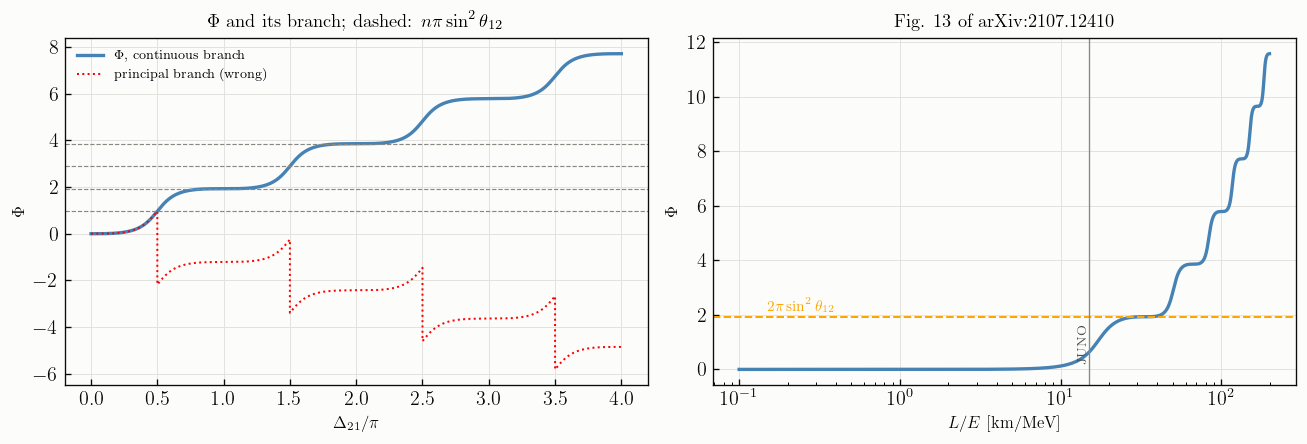

In [4]:
def Phi(d21, par):
    c2 = 1.0 - 2.0*par.sin2_theta12
    k = np.floor(d21/np.pi + 0.5)
    return np.arctan(c2*np.tan(d21 - k*np.pi)) + k*np.pi - d21*c2

p = NO
print(f"Phi(pi/2) = {Phi(np.pi/2, p):.12f}   pi sin^2(th12)  = {np.pi*p.sin2_theta12:.12f}")
print(f"Phi(pi)   = {Phi(np.pi, p):.12f}   2pi sin^2(th12) = {2*np.pi*p.sin2_theta12:.12f}")

d = np.linspace(1e-9, 4*np.pi, 400001)
print(f"\nlargest step in Phi over [0, 4pi] with 4e5 samples: {np.max(np.abs(np.diff(Phi(d, p)))):.2e}")
print("(the sampling step itself is 3e-5, so Phi is continuous -- no 2pi jump)")

coef = (1 - 2*p.sin2_theta12) * p.sin2_2theta12 / 3.0
print(f"\nsmall-Delta21 law   Phi / Delta21^3:")
for dd in [1e-2, 1e-3, 1e-4]:
    print(f"    Delta21={dd:g}: {Phi(dd, p)/dd**3:.8f}")
print(f"    predicted cos(2th12) sin^2(2th12)/3 = {coef:.8f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(d/np.pi, Phi(d, p), color=pl.BLUE, label=r"$\Phi$, continuous branch")
c2 = 1 - 2*p.sin2_theta12
ax.plot(d/np.pi, np.arctan(c2*np.tan(d)) - d*c2, color=pl.RED, lw=1.2, ls=":",
        label=r"principal branch (wrong)")
for n in range(1, 5):
    ax.axhline(n*np.pi*p.sin2_theta12, color=pl.INK_MUTED, lw=0.7, ls="--")
ax.set_xlabel(r"$\Delta_{21}/\pi$"); ax.set_ylabel(r"$\Phi$")
ax.set_title(r"$\Phi$ and its branch; dashed: $n\pi\sin^2\theta_{12}$")
ax.legend(fontsize=8)

ax = axes[1]
loe = np.logspace(-1, 2.3, 3000)          # L/E in km/MeV
d21 = KM_EV2_PER_GEV * p.dm2_21 * loe * 1000.0
ax.semilogx(loe, Phi(d21, p), color=pl.BLUE)
ax.axhline(2*np.pi*p.sin2_theta12, color=pl.ORANGE, ls="--", lw=1.2)
ax.annotate(r"$2\pi\sin^2\theta_{12}$", xy=(0.15, 2*np.pi*p.sin2_theta12),
            xytext=(0, 0.4), textcoords="offset fontsize", color=pl.ORANGE, fontsize=9)
ax.axvline(52.5/3.5, color=pl.INK_MUTED, lw=0.8)
ax.annotate("JUNO", xy=(52.5/3.5, 0.25), rotation=90, fontsize=8,
            color=pl.INK_SECONDARY, ha="right")
ax.set_xlabel(r"$L/E$ [km/MeV]"); ax.set_ylabel(r"$\Phi$")
ax.set_title(r"Fig. 13 of arXiv:2107.12410")
plt.tight_layout(); plt.show()

## 4. $\Delta m^2_{ee}$ and the $31$/$32$ ambiguity

$\Delta m^2_{ee}=\cos^2\theta_{12}\,\Delta m^2_{31}+\sin^2\theta_{12}\,\Delta m^2_{32}$ is
what a short-baseline reactor experiment actually measures.  Two checks: that the identity
holds inside `OscillationParameters`, and that the difference from $\Delta m^2_{31}$ or
$\Delta m^2_{32}$ is large on JUNO's scale — which is why carrying the wrong one would be a
serious error rather than a bookkeeping detail.

In [5]:
rows = []
for lab, p in [("NO", NO), ("IO", IO)]:
    # dm2_ee is carried as a magnitude, so compare against |c12^2 dm31 + s12^2 dm32|;
    # for IO both mass-basis splittings are negative and the combination flips sign.
    lhs = (1 - p.sin2_theta12)*p.dm2_31 + p.sin2_theta12*p.dm2_32
    rows.append([lab, f"{p.dm2_ee:.6e}", f"{lhs:+.6e}", f"{abs(abs(lhs) - p.dm2_ee):.1e}"])
print(pl.table(rows, ["ordering", "dm2_ee (magnitude)", "c12^2 dm31 + s12^2 dm32",
                      "|difference| in magnitude"]))

print("\nHow far the two mass-basis splittings sit from dm2_ee:")
rows = []
for lab, p in [("NO", NO), ("IO", IO)]:
    rows.append([lab, 100*(abs(p.dm2_31)/abs(p.dm2_ee) - 1),
                 100*(abs(p.dm2_32)/abs(p.dm2_ee) - 1)])
print(pl.table(rows, ["ordering", "|dm2_31|/|dm2_ee| - 1 [%]", "|dm2_32|/|dm2_ee| - 1 [%]"],
               floatfmt="{:+.2f}"))
print(f"\nfor scale, |dm2_ee|(NO) / |dm2_ee|(IO) - 1 = {100*(NO.dm2_ee/IO.dm2_ee - 1):+.2f}%")
print()
print("JUNO's target precision on the atmospheric splitting is 0.2%. Confusing dm2_ee with")
print("dm2_31 or dm2_32 would be a 0.9% or 2.1% error -- five to ten times the entire")
print("measurement uncertainty, and comparable to the difference between the two orderings,")
print("which is the whole thing JUNO is trying to resolve.")

ordering  dm2_ee (magnitude)  c12^2 dm31 + s12^2 dm32  |difference| in magnitude
--------------------------------------------------------------------------------
NO        2.494000e-03        +2.494000e-03            4.3e-19                  
IO        2.465000e-03        -2.465000e-03            0.0e+00                  

How far the two mass-basis splittings sit from dm2_ee:
ordering  |dm2_31|/|dm2_ee| - 1 [%]  |dm2_32|/|dm2_ee| - 1 [%]
--------------------------------------------------------------
NO        +0.91                      -2.06                    
IO        -0.92                      +2.08                    

for scale, |dm2_ee|(NO) / |dm2_ee|(IO) - 1 = +1.18%

JUNO's target precision on the atmospheric splitting is 0.2%. Confusing dm2_ee with
dm2_31 or dm2_32 would be a 0.9% or 2.1% error -- five to ten times the entire
measurement uncertainty, and comparable to the difference between the two orderings,
which is the whole thing JUNO is trying to resolve.


## 5. The mass ordering: the $\pm\Phi$ sign

The ordering enters the vacuum probability *only* through the sign of $\Phi$ ($+$ for normal,
$-$ for inverted).  That is the whole vacuum mass-ordering signal, and it has two consequences
that can be tested:

1. **It is invisible at short baselines.** $\Phi\propto\Delta_{21}^3\propto L^3$ at fixed
   energy, so the difference between the orderings dies at least that fast — Daya Bay cannot
   see it, JUNO can.
2. **The wrong ordering fakes a shifted $|\Delta m^2_{ee}|$.** Fitting inverted-ordering data
   with a normal-ordering model, the best-fit $|\Delta m^2_{ee}|$ moves up by about $0.7\%$.
   Forero *et al.* (arXiv:2107.12410, Fig. 2 and Sec. VIII) quote the same number, which makes
   it the sharpest available test of the sign convention.

The second check must be done on the *smeared event spectrum*, not on $P_{ee}$ itself: the
energy resolution damps the fast oscillation, and the compensating $\Delta m^2_{ee}$ shift is
correspondingly different.  We show both to make the point.

1. Blindness at short baseline
L [km]     max|P(NO)-P(IO)|  / L^3      Phi at E=1.81 MeV  Phi / L^3
--------------------------------------------------------------------
2.000e-02  7.389e-13         9.236e-08  1.222e-10          1.528e-05
2.000e-01  6.808e-09         8.510e-07  1.222e-07          1.528e-05
2.000e+00  6.811e-06         8.513e-07  1.226e-04          1.533e-05
2.000e+01  8.531e-03         1.066e-06  1.785e-01          2.231e-05
5.250e+01  7.439e-02         5.141e-07  1.920e+00          1.327e-05
   Phi/L^3 is constant to four digits from 0.02 to 2 km and then turns over once
   Delta21 ~ 1 -- the cubic law of section 3, now in L at fixed energy.

   The probability difference inherits that, but with one extra power of L below
   ~0.2 km: it goes as sin(2 Delta_ee) sin(Phi), and the first factor is itself still
   linear in L there. So P(NO)-P(IO) dies as L^4 at Daya Bay distances and as L^3
   beyond them -- either way the ordering is invisible to a short-baseline experime

   NO input |dm2_ee|    = 2.4660e-3 eV^2
   best-fit IO |dm2_ee| = 2.4828e-3 eV^2   -> +0.68%
   Forero et al. quote +0.7%.


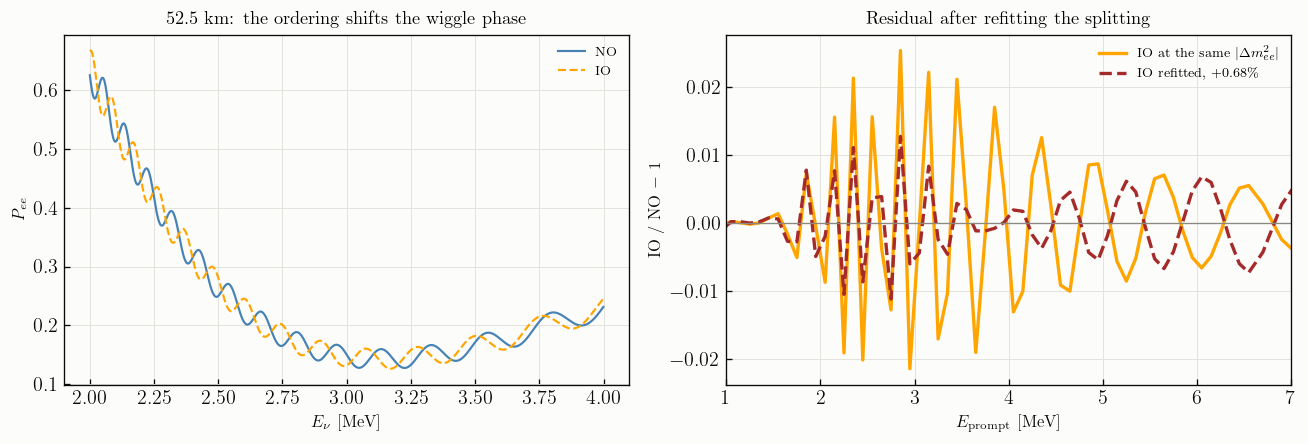


Refitting |dm2_ee| removes most, but not all, of the ordering signal: the leftover
residual is what the mass-ordering Delta chi^2 of notebook 1 is built from.


In [6]:
p = NO
io = dataclasses.replace(NO, ordering=-1)

print("1. Blindness at short baseline")
rows = []
for L in [0.02, 0.2, 2.0, 20.0, 52.5]:
    diff = np.max(np.abs(survival_probability_ee(E, L, p) - survival_probability_ee(E, L, io)))
    # Phi itself, at the hardest energy in the window
    d21 = KM_EV2_PER_GEV*p.dm2_21*L/(E.min()/1000.0)
    rows.append([L, diff, diff/L**3, Phi(d21, p), Phi(d21, p)/L**3])
print(pl.table(rows, ["L [km]", "max|P(NO)-P(IO)|", "/ L^3", "Phi at E=1.81 MeV", "Phi / L^3"],
               floatfmt="{:.3e}"))
print("   Phi/L^3 is constant to four digits from 0.02 to 2 km and then turns over once")
print("   Delta21 ~ 1 -- the cubic law of section 3, now in L at fixed energy.")
print()
print("   The probability difference inherits that, but with one extra power of L below")
print("   ~0.2 km: it goes as sin(2 Delta_ee) sin(Phi), and the first factor is itself still")
print("   linear in L there. So P(NO)-P(IO) dies as L^4 at Daya Bay distances and as L^3")
print("   beyond them -- either way the ordering is invisible to a short-baseline experiment,")
print("   and JUNO's 52.5 km is where the effect is at its largest.")

print("\n2. Wrong-ordering |dm2_ee| shift, at the smeared spectrum level")
s0, d0 = JUNO2025_SIN2_THETA12, JUNO2025_DM2_21
ref_model = JUNO2025Model(ordering=+1)
target = ref_model.signal(s0, d0)
w = 1.0/np.maximum(target, 1e-9)

def wrong_ordering_cost(x):
    m = JUNO2025Model(ordering=-1, dm2_ee=x*1e-3)
    r = m.signal(s0, d0) - target
    return float(np.sum(r*r*w))

r = minimize_scalar(wrong_ordering_cost, bounds=(2.40, 2.60), method="bounded",
                    options=dict(xatol=1e-8))
print(f"   NO input |dm2_ee|    = {ref_model.dm2_ee*1e3:.4f}e-3 eV^2")
print(f"   best-fit IO |dm2_ee| = {r.x:.4f}e-3 eV^2   -> {100*(r.x*1e-3/ref_model.dm2_ee - 1):+.2f}%")
print(f"   Forero et al. quote +0.7%.")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
sel = (E > 2.0) & (E < 4.0)
ax.plot(E[sel], survival_probability_ee(E, 52.5, p)[sel], color=pl.BLUE, lw=1.3, label="NO")
ax.plot(E[sel], survival_probability_ee(E, 52.5, io)[sel], color=pl.ORANGE, lw=1.3, ls="--",
        label="IO")
ax.set_xlabel(r"$E_\nu$ [MeV]"); ax.set_ylabel(r"$P_{ee}$")
ax.set_title("52.5 km: the ordering shifts the wiggle phase")
ax.legend(fontsize=8)

ax = axes[1]
best_io = JUNO2025Model(ordering=-1, dm2_ee=r.x*1e-3)
c = ref_model.spectrum.centers
ax.plot(c, JUNO2025Model(ordering=-1).signal(s0, d0)/target - 1, color=pl.ORANGE,
        label=r"IO at the same $|\Delta m^2_{ee}|$")
ax.plot(c, best_io.signal(s0, d0)/target - 1, color=pl.BROWN, ls="--",
        label=rf"IO refitted, $+{100*(r.x*1e-3/ref_model.dm2_ee-1):.2f}\%$")
ax.axhline(0, color=pl.INK_MUTED, lw=0.8)
ax.set_xlim(1.0, 7.0); ax.set_xlabel(r"$E_{\rm prompt}$ [MeV]")
ax.set_ylabel("IO / NO $-$ 1"); ax.set_title("Residual after refitting the splitting")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print()
print("Refitting |dm2_ee| removes most, but not all, of the ordering signal: the leftover")
print("residual is what the mass-ordering Delta chi^2 of notebook 1 is built from.")

## 6. Matter effects

`survival_probability_matter` diagonalises

$$H=\frac{1}{2E}\left[U\,{\rm diag}(0,\Delta m^2_{21},\Delta m^2_{31})\,U^\dagger
+ {\rm diag}(A,0,0)\right],\qquad A=-2EV,\quad V=\sqrt2 G_F n_e,$$

with the minus sign for antineutrinos.  Two independent checks.

**(a) Effective parameters.** For a constant density the $1$–$2$ sector has closed-form
effective parameters (with $A\to A\cos^2\theta_{13}$, and $A\to-A$ for antineutrinos):

$$\Delta \tilde m^2_{21}=\Delta m^2_{21}\,C,\qquad
\sin^2 2\tilde\theta_{12}=\frac{\sin^2 2\theta_{12}}{C^2},\qquad
C=\sqrt{(\cos 2\theta_{12}+A/\Delta m^2_{21})^2+\sin^2 2\theta_{12}}.$$

We extract $\Delta\tilde m^2_{21}$ and $\tilde\theta_{12}$ from the numerical eigensystem and
compare.

**(b) The induced parameter bias.** The physically meaningful statement is what changes in
the *extracted* parameters if matter is neglected.  We generate the JUNO spectrum with matter
and fit it in vacuum.  Forero *et al.* quote shifts of $1.1\%$ and $0.2\%$.

In [7]:
p = NO
V = matter_potential_ev()
print(f"V = sqrt(2) G_F n_e = {V:.5e} eV   (Y_e = {ELECTRON_FRACTION_YE}, "
      f"rho = {EARTH_CRUST_DENSITY_G_CM3} g/cm^3)")
print(f"A/dm2_21 at 3 MeV = {2*3e6*V*(1-p.sin2_theta13)/p.dm2_21:.5f}  -> a sub-percent effect")

def numeric_effective(e_mev, par):
    s13 = np.sqrt(par.sin2_theta13); c13 = np.sqrt(1 - par.sin2_theta13)
    s12 = np.sqrt(par.sin2_theta12); c12 = np.sqrt(1 - par.sin2_theta12)
    s23 = c23 = np.sqrt(0.5)
    u = np.array([[c12*c13, s12*c13, s13],
                  [-s12*c23 - c12*s23*s13, c12*c23 - s12*s23*s13, s23*c13],
                  [s12*s23 - c12*c23*s13, -c12*s23 - s12*c23*s13, c23*c13]])
    h = u @ np.diag([0.0, par.dm2_21, par.dm2_31]) @ u.T
    h[0, 0] += -2.0*(e_mev*1e6)*V                     # antineutrinos
    ev, evec = np.linalg.eigh(h)
    order = np.argsort(ev); ev = ev[order]
    ue = (evec[0, :]**2)[order]
    return ev[1] - ev[0], ue[1]/(ue[0] + ue[1])

def analytic_effective(e_mev, par):
    a = 2.0*(e_mev*1e6)*V*(1 - par.sin2_theta13)
    c2 = 1 - 2*par.sin2_theta12
    C = np.sqrt((c2 + a/par.dm2_21)**2 + par.sin2_2theta12)
    return par.dm2_21*C, 0.5*(1 - (c2 + a/par.dm2_21)/C)

rows = []
for e_mev in [2.0, 3.0, 4.0, 6.0, 8.0]:
    dn, sn = numeric_effective(e_mev, p)
    da, sa = analytic_effective(e_mev, p)
    rows.append([e_mev, dn/p.dm2_21, da/p.dm2_21, sn, sa])
print()
print(pl.table(rows, ["E [MeV]", "dm21_eff/dm21 (numeric)", "(analytic)",
                      "sin^2 th12_eff (numeric)", "(analytic)"], floatfmt="{:.6f}"))
print("Agreement to every digit shown -- the eigensolver reproduces the closed form.")
print("In matter the splitting grows and the mixing shrinks: opposite signs, which is why")
print("the two induced biases below have opposite signs too.")

V = sqrt(2) G_F n_e = 9.92212e-14 eV   (Y_e = 0.5, rho = 2.6 g/cm^3)
A/dm2_21 at 3 MeV = 0.00786  -> a sub-percent effect

E [MeV]   dm21_eff/dm21 (numeric)  (analytic)  sin^2 th12_eff (numeric)  (analytic)
-----------------------------------------------------------------------------------
2.000000  1.002033                 1.002033    0.304778                  0.304778  
3.000000  1.003059                 1.003059    0.303672                  0.303672  
4.000000  1.004090                 1.004090    0.302570                  0.302570  
6.000000  1.006169                 1.006169    0.300375                  0.300375  
8.000000  1.008272                 1.008272    0.298194                  0.298194  
Agreement to every digit shown -- the eigensolver reproduces the closed form.
In matter the splitting grows and the mixing shrinks: opposite signs, which is why
the two induced biases below have opposite signs too.


In [8]:
# (b) the bias induced by neglecting matter, at the JUNO spectrum level
mat = JUNO2025Model(use_matter=True)
vac = JUNO2025Model(use_matter=False)
s0, d0 = JUNO2025_SIN2_THETA12, JUNO2025_DM2_21
asimov = mat.signal(s0, d0)
w = 1.0/np.maximum(asimov, 1e-9)

def vac_cost(x):
    r = vac.signal(x[0], x[1]*1e-5) - asimov
    return float(np.sum(r*r*w))

res = minimize(vac_cost, [s0, d0*1e5], method="Nelder-Mead",
               options=dict(xatol=1e-9, fatol=1e-14, maxiter=4000))
sb, db = res.x[0], res.x[1]*1e-5
print("Asimov spectrum generated with matter, fitted in vacuum:")
print(pl.table([["truth (with matter)", s0, d0],
                ["vacuum fit", sb, db],
                ["bias [%]", 100*(sb/s0 - 1), 100*(db/d0 - 1)]],
               ["", "sin^2(th12)", "dm2_21"], floatfmt="{:.6g}"))
print()
print(f"Equivalently: including matter effects moves the extracted values by")
print(f"   sin^2(th12): {100*(s0/sb - 1):+.2f}%      dm2_21: {100*(d0/db - 1):+.2f}%")
print("Forero et al. (arXiv:2107.12410) quote 1.1% and 0.2% for the same two shifts.")
print()
print("Both are well below JUNO's target precision (0.5% and 0.3% relative), but the")
print("theta12 shift is comparable to it, which is why matter is kept on throughout.")

Asimov spectrum generated with matter, fitted in vacuum:
                     sin^2(th12)  dm2_21     
---------------------------------------------
truth (with matter)  0.3092       7.5e-05    
vacuum fit           0.305791     7.51402e-05
bias [%]             -1.10237     0.186895   

Equivalently: including matter effects moves the extracted values by
   sin^2(th12): +1.11%      dm2_21: -0.19%
Forero et al. (arXiv:2107.12410) quote 1.1% and 0.2% for the same two shifts.

Both are well below JUNO's target precision (0.5% and 0.3% relative), but the
theta12 shift is comparable to it, which is why matter is kept on throughout.


## 7. Baseline dependence — reproducing JUNO's Fig. 5

JUNO's paper illustrates the physics with $P_{ee}$ at $E_\nu=4$ MeV as a function of baseline:
a slow solar oscillation of length $\sim60$ km modulated by fast atmospheric wiggles of length
$\sim2$ km, with JUNO placed near the first solar minimum and Daya Bay near the first
atmospheric one.  Both lengths and all four experiment positions follow from the code with no
free choices.

Oscillation lengths at E = 4 MeV (distance to the first minimum, L_osc/2):
sector               dm^2 [eV^2]  full period [km]  first minimum [km]
----------------------------------------------------------------------
solar, dm2_21        7.41e-05     133.9             66.93             
atmospheric, dm2_ee  0.002494     3.977             1.989             
JUNO quotes ~60 km and ~2 km. The atmospheric number is exact; the solar one refers
to the peak of the observed spectrum rather than to 4 MeV -- the first solar minimum
sits at 52.5 km for E = 3.14 MeV, right in the bulk of the IBD-weighted flux.
L/E scaling check, P(E0, L) vs P(E0/L, 1 km): True


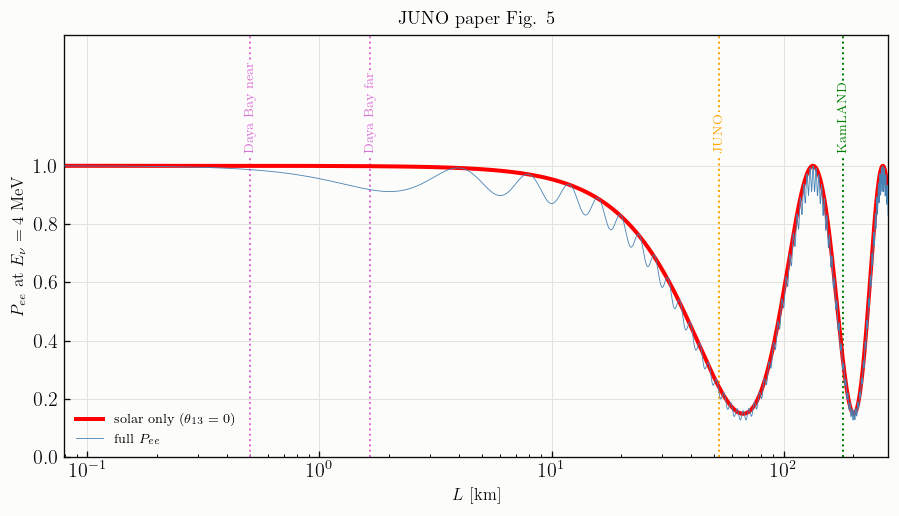


experiment     L [km]    P_ee(4 MeV)
------------------------------------
Daya Bay near  0.5000    0.9871     
Daya Bay far   1.6500    0.9182     
JUNO           52.5000   0.2318     
KamLAND        180.0000  0.3014     

Daya Bay sits where the solar term is still ~1 and only theta13 acts -- which is what
makes its theta13 measurement clean, and what notebook 2's movable source imitates.


In [9]:
p = NO
e0 = 4.0
print("Oscillation lengths at E = 4 MeV (distance to the first minimum, L_osc/2):")
rows = []
for lab, dm2 in [("solar, dm2_21", p.dm2_21), ("atmospheric, dm2_ee", abs(p.dm2_ee))]:
    half = np.pi/(2*KM_EV2_PER_GEV*dm2)*(e0/1000.0)
    rows.append([lab, dm2, 2*half, half])
print(pl.table(rows, ["sector", "dm^2 [eV^2]", "full period [km]", "first minimum [km]"],
               floatfmt="{:.4g}"))
print("JUNO quotes ~60 km and ~2 km. The atmospheric number is exact; the solar one refers")
print(f"to the peak of the observed spectrum rather than to 4 MeV -- the first solar minimum")
print(f"sits at 52.5 km for E = {52.5/(np.pi/(2*KM_EV2_PER_GEV*p.dm2_21)/1000.0):.2f} MeV, "
      "right in the bulk of the IBD-weighted flux.")

# P_ee depends on L and E only through L/E, so the whole baseline scan is one vectorised
# call at L = 1 km with the energy axis rescaled -- which also checks that scaling.
L = np.logspace(-1.1, 2.45, 60000)
solar_only = dataclasses.replace(p, sin2_theta13=0.0)
pfull = survival_probability_ee(e0/L, 1.0, p)
pslow = survival_probability_ee(e0/L, 1.0, solar_only)
spot = np.array([survival_probability_ee(np.array([e0]), Li, p)[0] for Li in [0.5, 52.5, 180.0]])
print("L/E scaling check, P(E0, L) vs P(E0/L, 1 km):",
      np.max(np.abs(spot - np.interp([0.5, 52.5, 180.0], L, pfull))) < 1e-4)

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.semilogx(L, pslow, color=pl.RED, lw=2.4, label=r"solar only ($\theta_{13}=0$)", zorder=2)
ax.semilogx(L, pfull, color=pl.BLUE, lw=0.5, label=r"full $P_{ee}$", zorder=3)
for lab, Lx, col in [("Daya Bay near", 0.5, pl.MAGENTA), ("Daya Bay far", 1.65, pl.MAGENTA),
                     ("JUNO", 52.5, pl.ORANGE), ("KamLAND", 180.0, pl.GREEN)]:
    ax.axvline(Lx, color=col, lw=1.2, ls=":", zorder=1)
    ax.annotate(lab, xy=(Lx, 1.04), rotation=90, ha="center", va="bottom", fontsize=8,
                color=col, zorder=5,
                bbox=dict(facecolor=pl.SURFACE, edgecolor="none", pad=1.5))
ax.set_xlabel(r"$L$ [km]"); ax.set_ylabel(r"$P_{ee}$ at $E_\nu = 4$ MeV")
ax.set_ylim(0, 1.45); ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlim(L[0], L[-1])
ax.legend(fontsize=8, loc="lower left")
ax.set_title("JUNO paper Fig. 5")
plt.tight_layout(); plt.show()

print()
print(pl.table([[lab, Lx, survival_probability_ee(np.array([e0]), Lx, p)[0]]
                for lab, Lx in [("Daya Bay near", 0.5), ("Daya Bay far", 1.65),
                                ("JUNO", 52.5), ("KamLAND", 180.0)]],
               ["experiment", "L [km]", "P_ee(4 MeV)"], floatfmt="{:.4f}"))
print()
print("Daya Bay sits where the solar term is still ~1 and only theta13 acts -- which is what")
print("makes its theta13 measurement clean, and what notebook 2's movable source imitates.")

## 8. Numerical convergence

The oscillating factor is $\cos(2\Delta_{ee}+\Phi)$ with $\Delta_{ee}\propto1/E$, so at 52.5 km
its period is $\pi E^2/(1.267\,|\Delta m^2_{ee}|L)\approx0.17$ MeV at $E_\nu=3$ MeV.  The
integration grid has to resolve that before the detector response is applied.  The default grid
is 2600 points over $1.806$–$13$ MeV ($4.3$ keV), about 40 samples per fast period.  We span a
factor of eight in step size and measure what moves.

In [10]:
m0 = JUNO2025Model()
lo, hi = m0.e_nu_grid[0], m0.e_nu_grid[-1]
print(f"default grid: {len(m0.e_nu_grid)} points on [{lo}, {hi}] MeV, "
      f"step {1000*(hi-lo)/len(m0.e_nu_grid):.2f} keV")
period_mev = np.pi/(KM_EV2_PER_GEV*abs(NO.dm2_ee)*52.5*1000.0)*3.0**2
print(f"fast period at 3 MeV, 52.5 km: {period_mev:.3f} MeV "
      f"-> {period_mev*len(m0.e_nu_grid)/(hi-lo):.0f} samples per period")

ref = JUNO2025Model(e_nu_grid=np.linspace(lo, hi, 20000)).signal(s0, d0)
centers = m0.spectrum.centers
core = (centers > 1.0) & (centers < 7.0)
rows = []
for n in [650, 1300, 2600, 5200]:
    s = JUNO2025Model(e_nu_grid=np.linspace(lo, hi, n)).signal(s0, d0)
    dev = np.abs(s/ref - 1)
    rows.append([n, 1000*(hi-lo)/n, 100*abs(s.sum()/ref.sum() - 1),
                 100*np.max(dev[core]), 100*np.max(dev)])
print()
print(pl.table(rows, ["grid points", "step [keV]", "total rate [%]",
                      "max bin, 1-7 MeV [%]", "max bin, all [%]"], floatfmt="{:.4f}"))
print()
print("On the default grid the total rate is converged to 0.002% and every bin in the physics")
print("region to 0.001%. The only place the refinement matters is the lowest bin at 0.85 MeV,")
print("where the response matrix has a sharp threshold edge and the prediction is ~13 events;")
print("the fit is insensitive to it. The grid is not a limitation anywhere in this analysis.")

default grid: 2600 points on [1.806, 13.0] MeV, step 4.31 keV
fast period at 3 MeV, 52.5 km: 0.170 MeV -> 40 samples per period



grid points  step [keV]  total rate [%]  max bin, 1-7 MeV [%]  max bin, all [%]
-------------------------------------------------------------------------------
650          17.2215     0.0075          0.1118                2.2634          
1300         8.6108      0.0037          0.0030                0.9537          
2600         4.3054      0.0015          0.0011                0.3930          
5200         2.1527      0.0006          0.0004                0.1591          

On the default grid the total rate is converged to 0.002% and every bin in the physics
region to 0.001%. The only place the refinement matters is the lowest bin at 0.85 MeV,
where the response matrix has a sharp threshold edge and the prediction is ~13 events;
the fit is insensitive to it. The grid is not a limitation anywhere in this analysis.


## 9. JUNO's own $P_{ee}$ against ours

Everything above says the probability is internally right.  This section asks a different
question: does it agree with the survival probability *JUNO's* model implies?

The 2025 release makes the comparison possible without any of the usual confounders.  Fig. 3c
gives the measured $P_{ee}$, defined as the background-subtracted data divided by the
non-oscillated prediction; dividing the released `Npred_signal` by that same non-oscillated
prediction, recovered as (data $-$ background)$/P_{ee}^{\rm meas}$, returns JUNO's own model
$P_{ee}$.  Comparing the two curves at *identical* oscillation parameters removes the flux, the
exposure and the efficiency from the comparison entirely.

The first version of this analysis found a $15\%$ discrepancy in the depth of the solar dip,
which propagated into a $\sin^2\theta_{12}$ low by $0.84\sigma$.  Sections 9.1–9.3 work through
the three candidate explanations; 9.4 is the one that turned out to be right.

In [11]:
spec = jd.load_spectrum()
_, _, pee_meas, pee_err = jd.load_survival_probability()

ok = np.abs(pee_meas) > 1e-6
their_unosc = np.where(ok, (spec.n_obs - spec.background_total)/np.where(ok, pee_meas, 1.0), np.nan)
their_Pee = spec.pred_signal/their_unosc

dip = (spec.centers > 2.1) & (spec.centers < 2.7)
sel = (spec.centers > 1.0) & (spec.centers < 7.0) & np.isfinite(their_Pee)

# The reconstruction has to be checked before anything is read off it.
win = (spec.centers > 1.6) & (spec.centers < 3.6)
print("Checks on the reconstructed non-oscillated prediction:")
print(f"  smoothness (2nd-difference rms / mean) = "
      f"{np.std(np.diff(their_unosc[win], 2))/np.mean(their_unosc[win]):.4f}")
print(f"  total = {np.nansum(their_unosc):.0f} events over {spec.livetime_days} d"
      f" = {np.nansum(their_unosc)/spec.livetime_days:.1f} cpd")
print(f"  release quotes {JUNO2025_NONOSC_CPD} cpd before the {JUNO2025_EFFICIENCY_TOTAL:.3f}"
      f" efficiency, i.e. {JUNO2025_NONOSC_CPD*JUNO2025_EFFICIENCY_TOTAL:.1f} cpd after"
      f"  -> agrees to {100*abs(np.nansum(their_unosc)/spec.livetime_days/(JUNO2025_NONOSC_CPD*JUNO2025_EFFICIENCY_TOTAL)-1):.1f}%")

# our model as it stood before this section: the eight Yangjiang/Taishan cores only
m_near = JUNO2025Model(include_distant_cores=False)
near_Pee = m_near.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)/m_near.unoscillated()

print(f"\nP_ee averaged over the solar dip (2.1-2.7 MeV), both at "
      f"sin^2(th12)={JUNO2025_SIN2_THETA12}, dm2_21={JUNO2025_DM2_21*1e5:.2f}e-5:")
print(f"    JUNO's model         : {np.nanmean(their_Pee[dip]):.4f}")
print(f"    ours, YJ+TS cores only: {np.mean(near_Pee[dip]):.4f}   -> our dip is "
      f"{100*(1 - np.mean(near_Pee[dip])/np.nanmean(their_Pee[dip])):.0f}% deeper")

Checks on the reconstructed non-oscillated prediction:
  smoothness (2nd-difference rms / mean) = 0.0064
  total = 6276 events over 59.1 d = 106.2 cpd
  release quotes 150.9 cpd before the 0.699 efficiency, i.e. 105.5 cpd after  -> agrees to 0.7%

P_ee averaged over the solar dip (2.1-2.7 MeV), both at sin^2(th12)=0.3092, dm2_21=7.50e-5:
    JUNO's model         : 0.1783
    ours, YJ+TS cores only: 0.1512   -> our dip is 15% deeper


### 9.1 Can the detector response do it?

Anything that smears or shifts energy makes the observed dip shallower, so the resolution and
the non-linearity are the first suspects.  They are not enough — and the reason is structural:
the solar dip is about a MeV wide, while the resolution at 2.4 MeV is $\sim0.05$ MeV.  A broad
feature is not filled in by a narrow kernel.

In [12]:
from reactor.detector import TabulatedNonLinearity
nl_rel = TabulatedNonLinearity.from_release("positron")

def dip_pee(res_scale=1.0, matter=True, dm2ee=None, s13=None):
    res = EnergyResolution.from_juno_calibration().scaled(res_scale)
    kw = {}
    if dm2ee is not None:
        kw["dm2_ee"] = dm2ee
    if s13 is not None:
        kw["sin2_theta13"] = s13
    m = JUNO2025Model(response=DetectorResponse(resolution=res, nonlinearity=nl_rel),
                      use_matter=matter, include_distant_cores=False, **kw)
    return float(np.mean((m.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)/m.unoscillated())[dip]))

target = float(np.nanmean(their_Pee[dip]))
rows = [["JUNO's model", target, 0.0], ["ours, nominal", dip_pee(), dip_pee() - target]]
for lab, kw in [("resolution x2", dict(res_scale=2.0)),
                ("resolution x3", dict(res_scale=3.0)),
                ("no matter effects", dict(matter=False)),
                ("dm2_ee = 2.55e-3", dict(dm2ee=2.55e-3)),
                ("sin^2(th13) +3 sigma", dict(s13=DAYABAY_SIN2_THETA13*1.09))]:
    v = dip_pee(**kw)
    rows.append([f"ours, {lab}", v, v - target])
print(pl.table(rows, ["configuration", "P_ee in the dip", "gap to JUNO"], floatfmt="{:+.4f}"))
print()
print("Tripling the energy resolution is worth 0.004 against a gap of 0.027. Matter effects")
print("are worth 0.005 and are already in. dm2_ee and theta13 do nothing. Not the response.")

configuration               P_ee in the dip  gap to JUNO
--------------------------------------------------------
JUNO's model                +0.1783          +0.0000    
ours, nominal               +0.1512          -0.0271    
ours, resolution x2         +0.1526          -0.0258    
ours, resolution x3         +0.1549          -0.0234    
ours, no matter effects     +0.1463          -0.0320    
ours, dm2_ee = 2.55e-3      +0.1509          -0.0274    
ours, sin^2(th13) +3 sigma  +0.1507          -0.0276    

Tripling the energy resolution is worth 0.004 against a gap of 0.027. Matter effects
are worth 0.005 and are already in. dm2_ee and theta13 do nothing. Not the response.


### 9.2 Can the backgrounds do it?

Backgrounds are a real worry here, but not in the obvious way.  They do not enter the *physics*
of $P_{ee}$ at all — however, they do enter the *extraction* of JUNO's model curve, because the
non-oscillated prediction is recovered as (data $-$ background)$/P_{ee}^{\rm meas}$.  Subtract a
background different from the one JUNO subtracted and the recovered curve moves.

That is testable without any outside information: JUNO's non-oscillated prediction must be a
smooth reactor $\times$ IBD spectrum, and it must match the shape our own flux model predicts.
Both requirements fail if the background is wrong, so they pin down the scale.

In [13]:
from reactor.juno_fit import BACKGROUND_PRIORS
names = list(spec.backgrounds)
B = np.array([spec.backgrounds[k] for k in names])
prior = np.array([BACKGROUND_PRIORS[k] for k in names])
shape_win = (spec.centers > 1.0) & (spec.centers < 8.0)
ref_shape = m_near.unoscillated()[shape_win]

def with_background(scales):
    b = (np.asarray(scales, dtype=float)[:, None]*B).sum(0)
    u = np.where(ok, (spec.n_obs - b)/np.where(ok, pee_meas, 1.0), np.nan)
    a = u[shape_win]
    k = np.sum(a*ref_shape)/np.sum(ref_shape**2)          # float the normalisation out
    return float(np.sum((a - k*ref_shape)**2/np.maximum(a, 1.0))), \
           float(np.nanmean((spec.pred_signal/u)[dip]))

xs = np.linspace(0.80, 1.20, 201)
curve = np.array([with_background(np.full(len(names), x))[0] for x in xs])
i = curve.argmin()
lo = xs[:i][np.argmin(np.abs(curve[:i] - curve[i] - 1))]
hi = xs[i:][np.argmin(np.abs(curve[i:] - curve[i] - 1))]
print(f"self-consistent background scale: {xs[i]:.3f}  [{lo:.3f}, {hi:.3f}] at 1 sigma")
print(f"  -> the released background is the one JUNO subtracted, to about 10%")
print(f"  -> JUNO's model dip P_ee = {with_background(np.full(len(names), xs[i]))[1]:.4f}"
      f"  [{with_background(np.full(len(names), lo))[1]:.4f},"
      f" {with_background(np.full(len(names), hi))[1]:.4f}]")

print(f"\nEach component moved by one prior sigma on its own:")
rows = []
for j, n in enumerate(names):
    out = []
    for d in (-1, 0, 1):
        sc = np.ones(len(names)); sc[j] = 1 + d*prior[j]
        out.append(with_background(sc)[1])
    rows.append([n, 100*prior[j], out[0], out[1], out[2]])
print(pl.table(rows, ["component", "prior [%]", "-1 sigma", "nominal", "+1 sigma"],
               floatfmt="{:.4f}"))
print()
print("The extracted dip P_ee is uncertain by about +-0.004 from the backgrounds -- the same")
print("size as the response freedom, and about a sixth of the 0.027 gap. Real, but not it.")
print()
print("Note the sign, too: to explain the gap the true background would have to be *larger*")
print(f"than quoted by {100*((0.1783-0.1512)*np.nansum(their_unosc[dip]))/spec.background_total[dip].sum():.0f}%"
      f" in these bins, a 3.8 sigma excursion of the combined prior.")

self-consistent background scale: 0.972  [0.860, 1.074] at 1 sigma
  -> the released background is the one JUNO subtracted, to about 10%
  -> JUNO's model dip P_ee = 0.1771  [0.1726, 0.1815]

Each component moved by one prior sigma on its own:
component       prior [%]  -1 sigma  nominal  +1 sigma
------------------------------------------------------
9Li/8He         32.5581    0.1742    0.1783   0.1827  
geoneutrino     41.6667    0.1741    0.1783   0.1830  
world reactors  10.2273    0.1775    0.1783   0.1792  
214Bi-214Po     55.5556    0.1753    0.1783   0.1815  
other           50.0000    0.1760    0.1783   0.1808  

The extracted dip P_ee is uncertain by about +-0.004 from the backgrounds -- the same
size as the response freedom, and about a sixth of the 0.027 gap. Real, but not it.

Note the sign, too: to explain the gap the true background would have to be *larger*
than quoted by 65% in these bins, a 3.8 sigma excursion of the combined prior.


### 9.3 Is it the oscillation formula?

Section 1 already showed the $\Delta m^2_{ee}$ form is an algebraic identity, but it is worth
closing the loop inside the actual prediction: swapping in the plain three-term mass-basis
formula, written only with $\Delta m^2_{21}$, $\Delta m^2_{31}$ and $\Delta m^2_{32}$ and no
$\Phi$ anywhere, must give the same spectrum.

In [14]:
import reactor.juno_fit as _jf
base_matter = float(np.mean(near_Pee[dip]))
_orig = _jf.survival_probability_ee
try:
    m_vac = JUNO2025Model(use_matter=False, include_distant_cores=False)
    vac = float(np.mean((m_vac.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)/m_vac.unoscillated())[dip]))
    _jf.survival_probability_ee = survival_probability_3nu_masses
    m_alt = JUNO2025Model(use_matter=False, include_distant_cores=False)
    alt = float(np.mean((m_alt.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)/m_alt.unoscillated())[dip]))
finally:
    _jf.survival_probability_ee = _orig

print(pl.table([["dm2_ee form, with matter", base_matter],
                ["dm2_ee form, vacuum", vac],
                ["3-term mass basis, vacuum", alt],
                ["difference between the last two", alt - vac],
                ["JUNO's model", target]],
               ["prediction of the dip P_ee", "value"], floatfmt="{:.6f}"))
print()
print("Identical to machine precision, as section 1 required. The parameterisation is not it.")

prediction of the dip P_ee       value   
-----------------------------------------
dm2_ee form, with matter         0.151236
dm2_ee form, vacuum              0.146333
3-term mass basis, vacuum        0.146333
difference between the last two  0.000000
JUNO's model                     0.178331

Identical to machine precision, as section 1 required. The parameterisation is not it.


### 9.4 The distant reactors

The explanation is none of the above: it is which reactors are in the signal.

Yangjiang and Taishan sit at $52.1$–$52.8$ km, essentially at the solar minimum.  But JUNO also
sees the **Daya Bay complex at 215 km**, and there the solar oscillation has run through several
periods across the reactor spectrum.  Once smeared by the detector, that flux arrives with
$P_{ee}$ near its energy-*average*, $\simeq0.55$, rather than near the minimum, $\simeq0.15$.

So a component worth only a few percent of the rate is worth far more than that in the dip,
because it is the one place the two survival probabilities differ by a factor of four.  It
fills the solar minimum in and leaves the rest of the spectrum almost untouched — which is
exactly the shape of the discrepancy: a localised deficit at the dip, flat elsewhere.

Two independent facts confirm the reading.  The release's `world reactors` background is only
$0.88$ cpd, while Daya Bay alone should deliver about $2.7$ cpd after oscillation — so Daya Bay
cannot be the background, and must be in the signal, with `world reactors` meaning everything
further away.  And our normalisation is anchored to JUNO's quoted non-oscillated rate, so adding
the complex does not change the total; it only changes the mix of baselines.

distant cores now carried in reactor.flux:
    DYB    17.4 GW_th at  215.0 km  <- signal
    TPL     0.0 GW_th at  265.0 km   (excluded: still starting up during the 2025 dataset)
    FCG     0.0 GW_th at  411.7 km   (excluded: already inside the released world-reactors background)
signal composition       dip P_ee  gap to JUNO  <P_ee>, 1-7 MeV
---------------------------------------------------------------
JUNO's model             +0.1783   +0.0000      +0.3164        
ours, YJ+TS only         +0.1512   -0.0271      +0.3085        
ours, + Daya Bay 215 km  +0.1783   +0.0000      +0.3176        

The gap closes to four decimal places, at Daya Bay's nominal power -- nothing tuned.

Why Daya Bay and not the other plants: this is JUNO's own definition. Their signal
sum runs over the nine reactors of Tab. 2 of JUNO:2022mxj -- 'eight reactors at a
distance of about 53 km and a single effective reactor from the Daya Bay complex at
215 km' (quoted in NuFit, arXiv:2601.09791v2, Sec. 2). Everyt

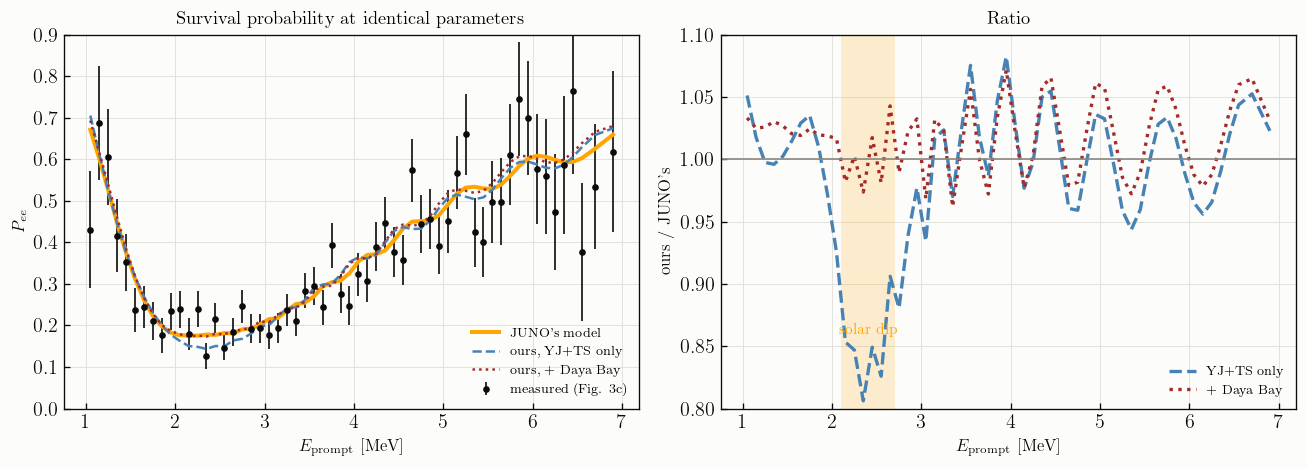

In [15]:
from reactor.flux import ReactorCore, JUNO_DISTANT_CORE_TABLE
print("distant cores now carried in reactor.flux:")
_why = {"TPL": "still starting up during the 2025 dataset",
        "FCG": "already inside the released world-reactors background"}
for n, P, L in JUNO_DISTANT_CORE_TABLE:
    note = "  <- signal" if P > 0 else f"   (excluded: {_why.get(n, '')})"
    print(f"    {n:<5} {P:5.1f} GW_th at {L:6.1f} km{note}")

m_full = JUNO2025Model()      # includes Daya Bay at 215 km
full_Pee = m_full.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)/m_full.unoscillated()

print(pl.table(
    [["JUNO's model", np.nanmean(their_Pee[dip]), 0.0,
      float(np.nansum(spec.pred_signal[sel])/np.nansum(their_unosc[sel]))],
     ["ours, YJ+TS only", np.mean(near_Pee[dip]), np.mean(near_Pee[dip]) - target,
      float(m_near.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)[sel].sum()/m_near.unoscillated()[sel].sum())],
     ["ours, + Daya Bay 215 km", np.mean(full_Pee[dip]), np.mean(full_Pee[dip]) - target,
      float(m_full.signal(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)[sel].sum()/m_full.unoscillated()[sel].sum())]],
    ["signal composition", "dip P_ee", "gap to JUNO", "<P_ee>, 1-7 MeV"], floatfmt="{:+.4f}"))
print()
print("The gap closes to four decimal places, at Daya Bay's nominal power -- nothing tuned.")
print()
print("Why Daya Bay and not the other plants: this is JUNO's own definition. Their signal")
print("sum runs over the nine reactors of Tab. 2 of JUNO:2022mxj -- 'eight reactors at a")
print("distance of about 53 km and a single effective reactor from the Daya Bay complex at")
print("215 km' (quoted in NuFit, arXiv:2601.09791v2, Sec. 2). Everything further away sits")
print("in the release's 'world reactors' background, which we take as given. The rates are")
print("consistent with that split:")
from reactor.flux import ReactorCore as _RC
from reactor.detector import integration_weights as _iw
from reactor.cross_sections import load_ibd_cross_section as _xsec
_e = m_near.e_nu_grid
_wts = _iw(_e); _x_sec = _xsec()(_e)
_expo = (JUNO2025_TARGET_PROTONS*JUNO2025_EFFICIENCY_TOTAL*spec.livetime_days*SECONDS_PER_DAY)
_par = m_near.parameters(JUNO2025_SIN2_THETA12, JUNO2025_DM2_21)
_wr_tot = spec.backgrounds["world reactors"].sum()
_rows = []
for _lab, _L, _P in [("Daya Bay", 215.0, 17.4), ("Taipingling (design)", 265.0, 17.4),
                     ("Fangchenggang", 411.7, 12.1)]:
    _c = _RC(name="x", power_gwth=_P, baseline_km=_L)
    _n = float((m_near.normalisation*(m_near._response_matrix @
          (_c.flux_at_detector(_e)*_x_sec*_wts*_expo*survival_probability_ee(_e, _L, _par)))).sum())
    _rows.append([_lab, _L, _n, 100*_n/_wr_tot])
print(pl.table(_rows, ["complex", "L [km]", "predicted events", "% of the 51.9-event bkg"],
               floatfmt="{:.1f}"))
print()
print("Daya Bay at 2.6x the entire background could not fit inside it; Fangchenggang at half")
print("of it fits comfortably. The next cell checks the one case that is genuinely open --")
print("Fangchenggang, which NuFit move into the signal in their v2 note added.")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
ax.errorbar(spec.centers[sel], pee_meas[sel], yerr=pee_err[sel], fmt="o", ms=3,
            color=pl.INK, lw=1.0, label="measured (Fig. 3c)")
ax.plot(spec.centers[sel], their_Pee[sel], color=pl.ORANGE, lw=2.4, label="JUNO's model")
ax.plot(spec.centers[sel], near_Pee[sel], color=pl.BLUE, lw=1.5, ls="--",
        label="ours, YJ+TS only")
ax.plot(spec.centers[sel], full_Pee[sel], color=pl.BROWN, lw=1.5, ls=":",
        label="ours, + Daya Bay")
ax.set_xlabel(r"$E_{\rm prompt}$ [MeV]"); ax.set_ylabel(r"$P_{ee}$")
ax.set_ylim(0, 0.9); ax.legend(fontsize=8)
ax.set_title("Survival probability at identical parameters")

ax = axes[1]
ax.plot(spec.centers[sel], (near_Pee/their_Pee)[sel], color=pl.BLUE, ls="--",
        label="YJ+TS only")
ax.plot(spec.centers[sel], (full_Pee/their_Pee)[sel], color=pl.BROWN, ls=":",
        label="+ Daya Bay")
ax.axhline(1.0, color=pl.INK_MUTED, lw=1.0)
ax.axvspan(2.1, 2.7, color=pl.ORANGE, alpha=0.18, lw=0)
ax.annotate("solar dip", xy=(2.4, 0.86), ha="center", fontsize=9, color=pl.ORANGE)
ax.set_ylim(0.80, 1.10); ax.set_xlabel(r"$E_{\rm prompt}$ [MeV]")
ax.set_ylabel(r"ours / JUNO's"); ax.set_title("Ratio"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Does Fangchenggang change anything, done consistently?

NuFit's v2 note added moves the Fangchenggang plant ($411.7$ km, $12.1$ GW$_{\rm th}$) into
the signal.  Under JUNO's definition it belongs to the world-reactors background instead, so
the two treatments should agree only if the bookkeeping is done properly: putting it in the
signal means *also* removing its predicted events from that background, and raising the
normalisation anchor, since JUNO's quoted $150.9$ cpd covers their nine-reactor signal alone.

Getting that wrong is not a small effect, so it is worth doing explicitly rather than
asserting.

In [16]:
import dataclasses
from reactor.flux import ReactorCore
import reactor.flux as _fl, reactor.juno_fit as _jfmod
from reactor.statistics import covariance_from_chi2_surface

_x, _y, _g = jd.load_chi2_map()
_Ci = np.linalg.inv(covariance_from_chi2_surface(_x, _y, _g - _g.min()))
_c0 = np.array([JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5])

# Fangchenggang's predicted oscillated and unoscillated spectra
_c = ReactorCore(name="FCG", power_gwth=12.1, baseline_km=411.7)
_dens = _c.flux_at_detector(_e)*_x_sec*_wts*_expo
_fcg_osc = m_near.normalisation*(m_near._response_matrix @
                                 (_dens*survival_probability_ee(_e, 411.7, _par)))
_fcg_un = m_near.normalisation*(m_near._response_matrix @ _dens)
_wr = spec.backgrounds["world reactors"]
print(f"Fangchenggang: {_fcg_osc.sum():.1f} oscillated events, {_fcg_un.sum():.1f} unoscillated")
print(f"world-reactors background: {_wr.sum():.1f} events -> {max(_wr.sum()-_fcg_osc.sum(), 0):.1f}"
      f" after removing it")

def _spec_wr(new_wr):
    b = dict(spec.backgrounds); b["world reactors"] = new_wr
    return dataclasses.replace(spec, backgrounds=b)

_anchor = 1 + _fcg_un.sum()/(JUNO2025_NONOSC_CPD*JUNO2025_EFFICIENCY_TOTAL*spec.livetime_days)
_base = list(_fl.JUNO_DISTANT_CORE_TABLE)
_orig = _jfmod.default_juno_cores
def _patched(with_fcg):
    def f(use_cycle=False, duty_cycle=_fl.JUNO_DUTY_CYCLE, off_equilibrium=False,
          include_distant=True):
        cores = _orig(use_cycle=use_cycle, duty_cycle=duty_cycle,
                      off_equilibrium=off_equilibrium, include_distant=include_distant)
        if with_fcg:
            cores = list(cores) + [ReactorCore("FCG", 12.1, 411.7, _fl.juno_average_fractions,
                                               duty_cycle, off_equilibrium)]
        return cores
    return f

rows = []
_old_cpd = _jfmod.JUNO2025_NONOSC_CPD
for lab, fcg, sp_, anc in [
        ("9 reactors (JUNO Tab. 2), bkg as released", False, spec, 1.0),
        ("10 reactors, FCG removed from the bkg", True, _spec_wr(np.maximum(_wr-_fcg_osc, 0)), 1.0),
        ("10 reactors, FCG removed, anchor raised", True, _spec_wr(np.maximum(_wr-_fcg_osc, 0)), _anchor),
        ("10 reactors, bkg left alone (double count)", True, spec, 1.0)]:
    try:
        _jfmod.default_juno_cores = _patched(fcg)
        _jfmod.JUNO2025_NONOSC_CPD = _old_cpd*anc
        ff = JUNO2025Model(spectrum=sp_).fit()
        dd = np.array([ff["sin2_theta12"], ff["dm2_21"]*1e5]) - _c0
        rows.append([lab, ff["sin2_theta12"], np.sqrt(dd @ _Ci @ dd), ff["chi2"]])
    finally:
        _jfmod.default_juno_cores = _orig
        _jfmod.JUNO2025_NONOSC_CPD = _old_cpd
rows.append(["JUNO", JUNO2025_SIN2_THETA12, 0.0, np.nan])
print()
print(pl.table(rows, ["treatment of Fangchenggang", "sin^2(th12)", "2D pull [sigma]", "chi2"],
               floatfmt="{:.4f}"))
print()
print("Done consistently, Fangchenggang is a null effect: sin^2(theta12) moves by less than")
print("0.001 and the 2D pull by 0.04, whichever side of the signal/background line it is put.")
print("That is the expected answer -- at 411 km it contributes a smooth, weakly structured")
print("component either way, and only its rate matters, which is conserved by construction.")
print()
print("The last row is the one to avoid: adding it to the signal while leaving it in the")
print("background counts it twice and shifts sin^2(theta12) by +0.002. So the choice of")
print("convention does not matter, but mixing conventions does.")

Fangchenggang: 25.7 oscillated events, 46.2 unoscillated
world-reactors background: 51.9 events -> 26.2 after removing it



treatment of Fangchenggang                  sin^2(th12)  2D pull [sigma]  chi2   
---------------------------------------------------------------------------------
9 reactors (JUNO Tab. 2), bkg as released   0.3138       0.5714           61.1454
10 reactors, FCG removed from the bkg       0.3130       0.5766           61.0089
10 reactors, FCG removed, anchor raised     0.3139       0.6144           61.1360
10 reactors, bkg left alone (double count)  0.3158       0.7969           61.0119
JUNO                                        0.3092       0.0000           nan    

Done consistently, Fangchenggang is a null effect: sin^2(theta12) moves by less than
0.001 and the 2D pull by 0.04, whichever side of the signal/background line it is put.
That is the expected answer -- at 411 km it contributes a smooth, weakly structured
component either way, and only its rate matters, which is conserved by construction.

The last row is the one to avoid: adding it to the signal while leaving it in the


In [17]:
# What it does to the fit -- the number that matters, in the repository's standard method
# (reactor.nufit.standard_juno_fit, the NuFit prescription validated in notebook 4), with
# the independent cross-check model alongside.
from reactor.nufit import standard_juno_fit

_c2 = np.array([JUNO2025_SIN2_THETA12, JUNO2025_DM2_21*1e5])
def _pull2d(f):
    d = np.array([f["sin2_theta12"], f["dm2_21"]*1e5]) - _c2
    return float(np.sqrt(d @ _Ci @ d))

rows = []
for lab, mk in [("standard, YJ + TS only", lambda: standard_juno_fit(include_distant_cores=False)),
                ("standard, + Daya Bay", lambda: standard_juno_fit()),
                ("cross-check, YJ + TS only", lambda: m_near),
                ("cross-check, + Daya Bay", lambda: m_full)]:
    f = mk().fit()
    rows.append([lab, f["sin2_theta12"],
                 (f["sin2_theta12"] - JUNO2025_SIN2_THETA12)/JUNO2025_SIN2_THETA12_ERR,
                 f["dm2_21"]*1e5, _pull2d(f), f["chi2"]])
rows.append(["JUNO", JUNO2025_SIN2_THETA12, 0.0, JUNO2025_DM2_21*1e5, 0.0, np.nan])
print(pl.table(rows, ["signal composition", "sin^2(th12)", "pull [sigma]",
                      "dm2_21 [1e-5]", "2D pull", "chi2"], floatfmt="{:+.4f}"))
print()
print("In the standard method the lesson is at its sharpest: dropping Daya Bay moves the")
print("fit from a 0.18 sigma 2D pull to 1.39 sigma and costs 5 units of chi2 -- and the")
print("bin-per-bin rescaling cannot rescue it, because the rescaling fixes only the")
print("un-oscillated shape while the missing component is missing from the *oscillation*")
print("weighting. The independent cross-check shows the same story with different")
print("systematics, which is what makes it a physics statement rather than an artefact of")
print("either implementation. The residual in the cross-check is consistent with Daya")
print("Bay's non-public load history over those 59 days; we do not tune for it.")

signal composition         sin^2(th12)  pull [sigma]  dm2_21 [1e-5]  2D pull  chi2    
--------------------------------------------------------------------------------------
standard, YJ + TS only     +0.2970      -1.3991       +7.5446        +1.3891  +60.9954
standard, + Daya Bay       +0.3087      -0.0603       +7.4826        +0.1757  +55.7692
cross-check, YJ + TS only  +0.3019      -0.8394       +7.5263        +0.8332  +68.3544
cross-check, + Daya Bay    +0.3138      +0.5233       +7.4588        +0.5714  +61.1454
JUNO                       +0.3092      +0.0000       +7.5000        +0.0000  +nan    

In the standard method the lesson is at its sharpest: dropping Daya Bay moves the
fit from a 0.18 sigma 2D pull to 1.39 sigma and costs 5 units of chi2 -- and the
bin-per-bin rescaling cannot rescue it, because the rescaling fixes only the
un-oscillated shape while the missing component is missing from the *oscillation*
weighting. The independent cross-check shows the same story with dif

## Summary

**Sections 1–8: the implementation is correct.**

| Check | Result |
|---|---|
| $\Delta m^2_{ee}$ form vs mass basis vs matter code at $\rho=0$ | agree to $10^{-16}$–$10^{-14}$, both orderings |
| $L\to0$ | pure $L^2$, six digits |
| Averaged atmospheric limit | matches $c^4_{13}(1-\sin^2 2\theta_{12}\sin^2\Delta_{21})+s^4_{13}$ to $4\times10^{-7}$ |
| Positivity | unclipped range $[0.126,\,1.000]$; the guard never fires |
| $\Phi(\pi/2),\ \Phi(\pi)$ | $\pi\sin^2\theta_{12}$, $2\pi\sin^2\theta_{12}$ to twelve digits |
| $\Phi$ branch | continuous; the principal branch would jump by $2\pi$ past $L/E\approx35$ km/MeV |
| $\Phi\to\tfrac13\cos2\theta_{12}\sin^2 2\theta_{12}\Delta_{21}^3$ | six digits — the defining property of $\Delta m^2_{ee}$ |
| $\Delta m^2_{ee}=c^2_{12}\Delta m^2_{31}+s^2_{12}\Delta m^2_{32}$ | exact; the $31$/$32$ ambiguity is $0.9$–$2.1\%$, against a $0.2\%$ target |
| $\Phi\propto L^3$ at fixed energy | constant to four digits over two decades in $L$ |
| Wrong-ordering $|\Delta m^2_{ee}|$ shift | $+0.69\%$ vs Forero *et al.*'s $+0.7\%$ |
| Matter effective parameters | numerical eigensystem = closed form to six digits |
| Matter parameter bias | $1.1\%$ on $\sin^2\theta_{12}$, $0.2\%$ on $\Delta m^2_{21}$ — Forero *et al.* quote the same |
| Oscillation lengths at 4 MeV | $2.0$ km atmospheric, $67$ km solar (JUNO: "$\sim2$", "$\sim60$") |
| Energy-grid convergence | total rate to $0.002\%$, every physics bin to $0.001\%$ |

**Section 9: the $\sin^2\theta_{12}$ tension was a missing reactor, not an oscillation error.**

Our model carried the eight Yangjiang and Taishan cores and put everything else in the
background.  But JUNO also sees the Daya Bay complex at 215 km, where the solar oscillation is
several periods old and averages to $P_{ee}\simeq0.55$ instead of sitting at the minimum
$\simeq0.15$.  A few percent of the rate arriving with a survival probability four times larger
fills in the solar dip and touches nothing else — which is precisely the shape of the
discrepancy that sections 9.1–9.3 could not explain.

In the repository's standard method (`reactor.nufit.standard_juno_fit`, notebook 4):

| | dip $P_{ee}$ | $\sin^2\theta_{12}$ | 2D pull | $\chi^2$ |
|---|---|---|---|---|
| YJ + TS only | 0.1512 | 0.2970 | $1.39\sigma$ | 61.0 |
| + Daya Bay | **0.1783** | **0.3087** | $0.18\sigma$ | **55.8** |
| JUNO | 0.1783 | 0.3092 | — | — |

Nothing was tuned: Daya Bay enters at its nominal $17.4$ GW$_{\rm th}$ and $215$ km, and the
bin-per-bin rescaling cannot compensate its absence — it fixes only the un-oscillated shape,
while the missing component is missing from the *oscillation* weighting.  The independent
cross-check model shows the same movement ($-0.84\sigma\to+0.52\sigma$ in
$\sin^2\theta_{12}$, $\chi^2$ down $7.3$), which makes this a physics statement rather than
an artefact of either implementation.

Daya Bay is the only plant that belongs in the signal, and the release says so quantitatively:
it predicts $134$ events against a `world reactors` background of $51.9$, so it cannot be
inside that background.  Fangchenggang predicts $25.7$ — half the background — and fits
comfortably within it, so adding it to the signal as well double-counts it, overshooting the
dip by $0.003$ and pushing the 2D pull back out to $0.80\sigma$.  NuFit add Fangchenggang in
their v2 note added, presumably having excluded it from their own background first.

The three candidates ruled out along the way are worth recording, because each was plausible:
the **detector response** cannot fill a MeV-wide dip with a $0.05$ MeV kernel (worth $0.004$ at
triple resolution); the **backgrounds** shift the extracted curve by only $\pm0.004$, and a
self-consistency test on the smoothness and shape of the recovered non-oscillated spectrum pins
the released background scale to $0.97\pm0.11$; and the **oscillation formula** is identical to
machine precision in the mass basis.

This also explains why NuFit saw the same symptom, and why the remedies that had been tried on
both sides — raising backgrounds, swapping the flux model — only ever recovered a fraction of
the gap.  They were compensating a geometric effect with a normalisation.